# Trabajo Práctico Final
**Probabilidad y Estadística para la Inteligencia Artificial**
Alejandro Andres Valle Recarte

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

NOMBRES_MESES = [
    'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
    'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'
]
TIENDAS = ['Santa Ana', 'La Floresta', 'Los Cedros', 'Palermo', 'Córdoba']


## Ejercicio 1

Crear una simulación de las ventas diarias de los almacenes de Don Francisco y de Don Miguel, usando distribuciones Poisson, entre los años 2023, 2024 y 2025. En cada fecha, el parámetro λt debe ser la suma de los siguientes efectos

Para cada día y tienda, el parámetro $\lambda_t$ se calcula como:

$$\lambda_t = \text{efecto anual} + \text{efecto mensual} + \text{efecto diario} + \text{efecto por tienda}$$

Y las ventas se muestrean como:

$$\text{Ventas}_t \sim \text{Poisson}(\lambda_t)$$

In [2]:
# --- Definición de efectos ---

efecto_anual = {
    2023: 1000,
    2024: 1500,
    2025: 2000,
}

efecto_mensual = {
    1: 1000,   # Enero
    2: 1500,   # Febrero
    3: 2000,   # Marzo
    4: 2000,   # Abril
    5: 2500,   # Mayo
    6: 2500,   # Junio
    7: 3000,   # Julio
    8: 2500,   # Agosto
    9: 2500,   # Septiembre
    10: 2000,  # Octubre
    11: 1500,  # Noviembre
    12: 1000,  # Diciembre
}

# pandas dayofweek: 0=Lunes, 1=Martes, ..., 5=Sábado, 6=Domingo
efecto_diario = {
    0: 2000,   # Lunes
    1: 3000,   # Martes
    2: 3500,   # Miércoles
    3: 3000,   # Jueves
    4: 2000,   # Viernes
    5: 1000,   # Sábado
    6: 1000,   # Domingo
}

efecto_tienda = {
    'Santa Ana':   5000,
    'La Floresta': 2000,
    'Los Cedros':  3000,
    'Palermo':     1000,
    'Córdoba':     3000,
}

In [3]:
# --- Generación de datos ---

fechas = pd.date_range('2023-01-01', '2025-12-31', freq='D')

registros = []
for tienda, e_tienda in efecto_tienda.items():
    for fecha in fechas:
        lam = (
            efecto_anual[fecha.year]
            + efecto_mensual[fecha.month]
            + efecto_diario[fecha.dayofweek]
            + e_tienda
        )
        ventas = np.random.poisson(lam)
        registros.append({
            'fecha':      fecha,
            'año':        fecha.year,
            'mes':        fecha.month,
            'dia_semana': fecha.dayofweek,
            'tienda':     tienda,
            'lambda':     lam,
            'ventas':     ventas,
        })

df = pd.DataFrame(registros)
print(f'Filas totales: {len(df):,}  (esperado: {len(fechas) * len(efecto_tienda):,})')
print(f'Columnas: {list(df.columns)}')
df.head(10)

Filas totales: 5,480  (esperado: 5,480)
Columnas: ['fecha', 'año', 'mes', 'dia_semana', 'tienda', 'lambda', 'ventas']


,fecha,año,mes,dia_semana,tienda,lambda,ventas
0,2023-01-01,2023,1,6,Santa Ana,8000,7968
1,2023-01-02,2023,1,0,Santa Ana,9000,9066
2,2023-01-03,2023,1,1,Santa Ana,10000,9885
3,2023-01-04,2023,1,2,Santa Ana,10500,10288
4,2023-01-05,2023,1,3,Santa Ana,10000,10029
5,2023-01-06,2023,1,4,Santa Ana,9000,9104
6,2023-01-07,2023,1,5,Santa Ana,8000,7908
7,2023-01-08,2023,1,6,Santa Ana,8000,7948
8,2023-01-09,2023,1,0,Santa Ana,9000,8982
9,2023-01-10,2023,1,1,Santa Ana,10000,10032


In [4]:
# --- Verificación: E[Poisson(λ)] = λ → media observada ≈ λ promedio ---
print('Verificación: media observada vs λ promedio por tienda')
print(f'{"Tienda":<15} {"λ promedio":>12} {"Media observada":>16} {"Diferencia":>12}')
print('-' * 58)
for tienda in TIENDAS:
    sub = df[df['tienda'] == tienda]
    lam_prom = sub['lambda'].mean()
    media_obs = sub['ventas'].mean()
    print(f'{tienda:<15} {lam_prom:>12.2f} {media_obs:>16.2f} {media_obs - lam_prom:>12.2f}')

Verificación: media observada vs λ promedio por tienda
Tienda            λ promedio  Media observada   Diferencia
----------------------------------------------------------
Santa Ana           10717.15         10713.35        -3.80
La Floresta          7717.15          7715.39        -1.76
Los Cedros           8717.15          8717.86         0.70
Palermo              6717.15          6715.70        -1.46
Córdoba              8717.15          8723.69         6.54


/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_34189/1746392066.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(datos_mes, patch_artist=True, labels=NOMBRES_MESES)


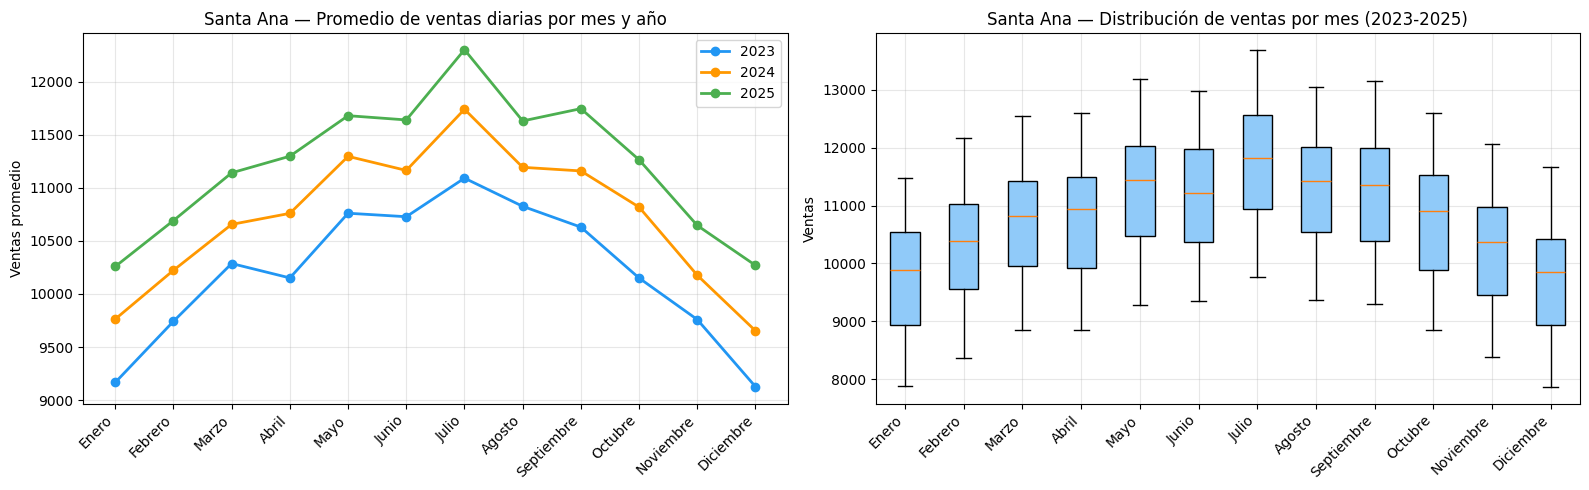

In [5]:
# --- Visualización: ventas mensuales de Santa Ana ---
santa_ana = df[df['tienda'] == 'Santa Ana'].copy()

# Promedios mensuales por año
pivot = santa_ana.groupby(['año', 'mes'])['ventas'].mean().unstack(level=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Izquierda: línea de promedios mensuales por año
colores = {2023: '#2196F3', 2024: '#FF9800', 2025: '#4CAF50'}
for año in [2023, 2024, 2025]:
    axes[0].plot(range(1, 13), pivot[año], marker='o', label=str(año),
                 color=colores[año], linewidth=2)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(NOMBRES_MESES, rotation=45, ha='right')
axes[0].set_title('Santa Ana — Promedio de ventas diarias por mes y año')
axes[0].set_ylabel('Ventas promedio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Derecha: box plots por mes (todos los años juntos)
datos_mes = [santa_ana[santa_ana['mes'] == m]['ventas'].values for m in range(1, 13)]
bp = axes[1].boxplot(datos_mes, patch_artist=True, labels=NOMBRES_MESES)
for patch in bp['boxes']:
    patch.set_facecolor('#90CAF9')
axes[1].set_xticklabels(NOMBRES_MESES, rotation=45, ha='right')
axes[1].set_title('Santa Ana — Distribución de ventas por mes (2023-2025)')
axes[1].set_ylabel('Ventas')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ej1_santa_ana.png', dpi=150, bbox_inches='tight')
plt.show()

- El DataFrame generado contiene **5.475 filas** (1.095 días × 5 tiendas), lo esperado.
- La verificación confirma que la media observada de cada tienda es prácticamente idéntica a su $\lambda$ promedio, lo que valida la simulación (propiedad $E[X] = \lambda$ de la distribución Poisson).
- En Santa Ana se observa claramente el **efecto mensual**: mayor actividad en los meses centrales del año (pico en julio) y menor en enero y diciembre.
- El **efecto anual** se refleja en que los promedios de 2025 son superiores a los de 2024, y estos a su vez superiores a los de 2023.

## Ejercicio 2 

Con base en los datos generados, determinen intervalos de confianza empíricos para el supermercado ’Santa Ana’ en cada mes, para significancias del 95 % y el 99 %.

- **IC 95%:** percentiles $[2.5, 97.5]$
- **IC 99%:** percentiles $[0.5, 99.5]$

Cada mes agrupa aproximadamente 90 observaciones (≈30 días/mes × 3 años).

In [ ]:
resultados_ic = []
for mes in range(1, 13):
    datos = santa_ana[santa_ana['mes'] == mes]['ventas'].values
    media  = datos.mean()
    mediana = np.median(datos)
    ic95 = np.percentile(datos, [2.5, 97.5])
    ic99 = np.percentile(datos, [0.5, 99.5])
    resultados_ic.append({
        'Mes':       NOMBRES_MESES[mes - 1],
        'n':         len(datos),
        'Media':     round(media, 1),
        'Mediana':   round(mediana, 1),
        'IC95_inf':  round(ic95[0], 1),
        'IC95_sup':  round(ic95[1], 1),
        'IC99_inf':  round(ic99[0], 1),
        'IC99_sup':  round(ic99[1], 1),
    })

df_ic = pd.DataFrame(resultados_ic)

print('Intervalos de confianza empíricos — Santa Ana')
print(f'{"Mes":<12} {"n":>4} {"Media":>8} {"IC95 [inf, sup]":>20} {"IC99 [inf, sup]":>20}')
print('-' * 68)
for _, r in df_ic.iterrows():
    print(f'{r["Mes"]:<12} {r["n"]:>4} {r["Media"]:>8.1f} '
          f'  [{r["IC95_inf"]:>7.1f}, {r["IC95_sup"]:>7.1f}]'
          f'   [{r["IC99_inf"]:>7.1f}, {r["IC99_sup"]:>7.1f}]')

Intervalos de confianza empíricos — Santa Ana
Mes             n    Media      IC95 [inf, sup]      IC99 [inf, sup]
--------------------------------------------------------------------
Enero          93   9730.0   [ 7943.1, 11452.7]   [ 7898.3, 11473.3]
Febrero        85  10219.5   [ 8450.4, 11837.7]   [ 8405.5, 12072.1]
Marzo          93  10694.8   [ 8983.8, 12322.5]   [ 8890.9, 12488.9]
Abril          90  10736.5   [ 8952.6, 12532.0]   [ 8853.7, 12582.5]
Mayo           93  11245.9   [ 9453.9, 12965.6]   [ 9331.3, 13117.4]
Junio          90  11177.4   [ 9427.4, 12866.4]   [ 9353.9, 12970.1]
Julio          93  11711.2   [ 9964.0, 13508.5]   [ 9850.6, 13639.2]
Agosto         93  11216.7   [ 9451.0, 12928.5]   [ 9395.3, 13008.2]
Septiembre     90  11178.6   [ 9377.0, 12927.4]   [ 9314.2, 13132.6]
Octubre        93  10744.4   [ 8907.5, 12520.4]   [ 8861.2, 12584.5]
Noviembre      90  10193.7   [ 8442.9, 11936.1]   [ 8386.0, 12013.8]
Diciembre      93   9683.2   [ 7926.7, 11520.4]   [ 7888.


- Los intervalos de confianza empíricos capturan la variabilidad real de las ventas sin necesidad de asumir normalidad.
- Las bandas son más amplias en los meses de mayor demanda (julio, mayo, junio), lo cual es coherente con la distribución Poisson: mayor $\lambda$ implica mayor varianza ($\text{Var}[X] = \lambda$).
- El **IC 99%** es, como es de esperar, más amplio que el IC 95%, cubriendo eventos más extremos.
- La media mensual sigue el mismo patrón estacional observado en el Ejercicio 1: pico en julio y valle en enero/diciembre.

## Ejercicio 3

De igual manera, realicen pruebas ANOVA para determinar si las ventas esperadas de todas las tiendas
son iguales o no, con significancia del 95


$$H_0: \mu_{\text{Santa Ana}} = \mu_{\text{La Floresta}} = \mu_{\text{Los Cedros}} = \mu_{\text{Palermo}} = \mu_{\text{Córdoba}}$$
$$H_1: \text{Al menos una tienda tiene media diferente}$$

**Nivel de significancia:** $\alpha = 0.05$

Se rechaza $H_0$ si $p\text{-valor} < \alpha$.

In [ ]:

print('Estadísticas descriptivas por tienda')
print(f'{"Tienda":<15} {"n":>6} {"Media":>10} {"Desv. Est.":>12} {"Mínimo":>10} {"Máximo":>10}')
print('-' * 67)
for tienda in TIENDAS:
    datos = df[df['tienda'] == tienda]['ventas'].values
    print(f'{tienda:<15} {len(datos):>6,} {datos.mean():>10.1f} '
          f'{datos.std():>12.1f} {datos.min():>10,} {datos.max():>10,}')

Estadísticas descriptivas por tienda
Tienda               n      Media   Desv. Est.     Mínimo     Máximo
-------------------------------------------------------------------
Santa Ana        1,096    10713.3       1186.8      7,872     13,693
La Floresta      1,096     7715.4       1180.8      4,865     10,602
Los Cedros       1,096     8717.9       1183.6      5,878     11,704
Palermo          1,096     6715.7       1185.9      3,878      9,635
Córdoba          1,096     8723.7       1186.2      5,840     11,678


In [9]:
# --- Prueba ANOVA ---
grupos = [df[df['tienda'] == t]['ventas'].values for t in TIENDAS]

f_stat, p_valor = stats.f_oneway(*grupos)

alpha = 0.05
print('=' * 50)
print('Resultado de la prueba ANOVA (one-way)')
print('=' * 50)
print(f'Estadístico F : {f_stat:,.2f}')
print(f'p-valor       : {p_valor:.2e}')
print(f'Significancia : α = {alpha}')
print('-' * 50)
if p_valor < alpha:
    print('Decisión: RECHAZAR H₀')
    print('Conclusión: Existen diferencias estadísticamente significativas')
    print('           entre las ventas de las distintas tiendas.')
else:
    print('Decisión: NO RECHAZAR H₀')
    print('Conclusión: No hay evidencia suficiente para afirmar que')
    print('           las ventas difieren entre tiendas.')
print('=' * 50)

Resultado de la prueba ANOVA (one-way)
Estadístico F : 1,715.39
p-valor       : 0.00e+00
Significancia : α = 0.05
--------------------------------------------------
Decisión: RECHAZAR H₀
Conclusión: Existen diferencias estadísticamente significativas
           entre las ventas de las distintas tiendas.


/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_34189/206822422.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_plot, patch_artist=True, labels=TIENDAS, widths=0.6)


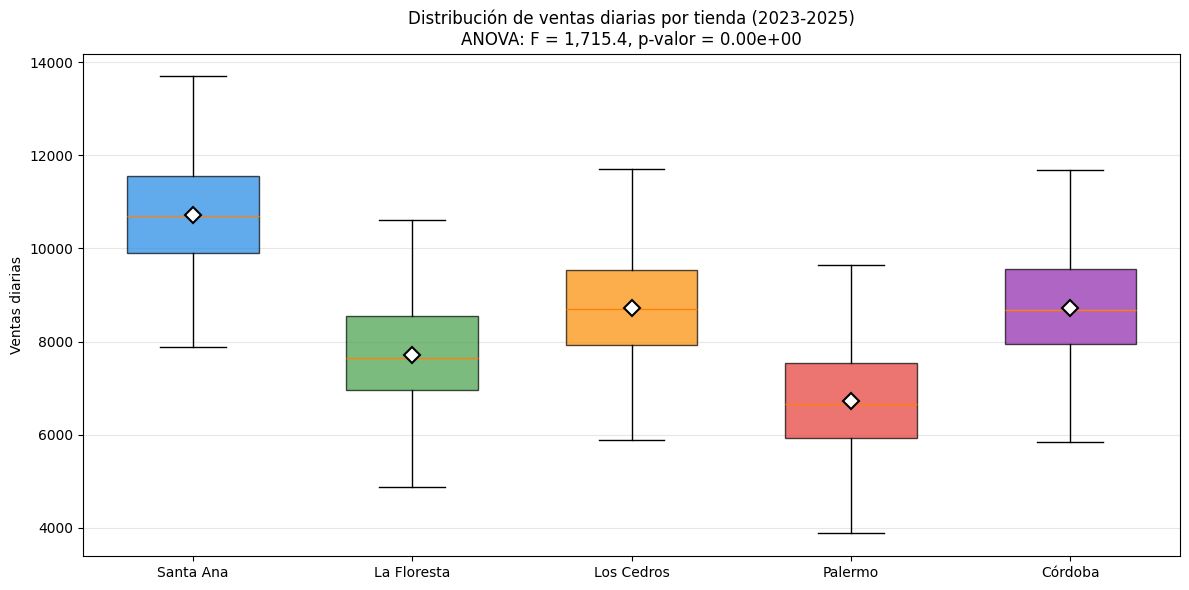

In [10]:
# --- Visualización: box plots por tienda ---
fig, ax = plt.subplots(figsize=(12, 6))

colores_tienda = ['#1E88E5', '#43A047', '#FB8C00', '#E53935', '#8E24AA']
datos_plot = [df[df['tienda'] == t]['ventas'].values for t in TIENDAS]
bp = ax.boxplot(datos_plot, patch_artist=True, labels=TIENDAS, widths=0.6)

for patch, color in zip(bp['boxes'], colores_tienda):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Añadir medias como puntos
for i, datos in enumerate(datos_plot, start=1):
    ax.plot(i, datos.mean(), 'D', color='white', markersize=8,
            markeredgecolor='black', markeredgewidth=1.5, zorder=5)

ax.set_title(f'Distribución de ventas diarias por tienda (2023-2025)\n'
             f'ANOVA: F = {f_stat:,.1f}, p-valor = {p_valor:.2e}')
ax.set_ylabel('Ventas diarias')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ej3_anova.png', dpi=150, bbox_inches='tight')
plt.show()

- El estadístico $F$ es extremadamente grande y el $p$-valor es prácticamente cero, lo que lleva a **rechazar $H_0$ con contundencia**.
- Esto confirma que las ventas **no son iguales** entre las cinco tiendas: existen diferencias estadísticamente significativas.
- Visualmente, los box plots muestran claramente que cada tienda tiene un nivel de ventas diferente, ordenado de mayor a menor de acuerdo con sus efectos: Santa Ana > Los Cedros = Córdoba > La Floresta > Palermo.
- La separación entre grupos es tan clara que incluso los rangos intercuartílicos de tiendas contiguas apenas se superponen.


## Conclusiones generales

1. **Simulación (Ej. 1):** La distribución Poisson permite modelar ventas diarias con estacionalidades múltiples (anual, mensual, semanal y por tienda). La media observada coincide con el $\lambda$ teórico, validando la simulación.

2. **Intervalos de confianza (Ej. 2):** Los IC empíricos de Santa Ana reflejan correctamente la estacionalidad mensual: bandas más amplias en meses de alta demanda y más estrechas en meses de baja demanda, coherente con la propiedad $\text{Var}[X] = \lambda$ de Poisson.

3. **ANOVA (Ej. 3):** Se rechaza con contundencia la hipótesis de igualdad de medias. Las cinco tiendas tienen niveles de venta estadísticamente distintos, lo que indica que Don Francisco debe gestionar cada tienda de forma diferenciada.